# Spatial embedding generation (Experiment C)

Compute and **cache** spatial-domain embeddings for all 12 DLPFC sections using three graph-based
encoders, under one common preprocessing and evaluation protocol:

| Encoder  | Framework      | Embedding dim | Spatial graph |
|----------|----------------|---------------|---------------|
| STAGATE  | TensorFlow 1.x | 30            | k-NN (k=6)    |
| GraphST  | PyTorch        | 64            | k-NN (k=3)    |
| SpaGCN   | PyTorch        | 50            | distance kernel (p=0.5) |

For every section each encoder is trained on the 3000 highly variable genes, the learned embedding is
saved to `experiment_c_embeddings/{section}_{encoder}_embedding.npy`, and KMeans (with k = ground-truth
number of layers) is used purely as a *common yardstick* to score the representations (ARI / NMI).

> The cached `.npy` embeddings are the real output of this notebook. The downstream pipelines
> (`fusion_experiment`, `pipeline_embeddings`) load them directly so the heavy encoders never have to
> be re-run. This notebook is the only place TensorFlow is required.


## Environment setup

STAGATE is built on the TensorFlow 1.x graph API, so eager execution must be disabled **before**
importing it. The remaining cells import the PyTorch encoders (GraphST, SpaGCN), fix all random seeds
for reproducibility, and patch the deprecated `scipy.sparse.*.A` attribute that some encoders still rely on.


In [1]:
import tensorflow as tf

tf.compat.v1.disable_eager_execution()

print("TensorFlow eager:", tf.executing_eagerly())

import STAGATE

TensorFlow eager: False


/Users/muradyan.e/wut/bioinform/.venv/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
import os
import random
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)

import torch

# import STAGATE
import GraphST
import SpaGCN
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

/Users/muradyan.e/wut/bioinform/.venv/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/muradyan.e/wut/bioinform/.venv/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/muradyan.e/wut/bioinform/.venv/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)


In [3]:
sections = [
    "151507", "151508", "151509", "151510",
    "151669", "151670", "151671", "151672",
    "151673", "151674", "151675", "151676"
]

In [4]:
import scipy.sparse as sp

if not hasattr(sp.csr_matrix, "A"):
    sp.csr_matrix.A = property(lambda self: self.toarray())

if not hasattr(sp.csc_matrix, "A"):
    sp.csc_matrix.A = property(lambda self: self.toarray())

test = sp.csr_matrix(np.eye(3))

print(test.A)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


## Common clustering function

In [5]:
def cluster_embedding(
    embedding,
    n_clusters,
    seed=42
):

    X = np.asarray(embedding)

    # Standardize each embedding independently
    X = StandardScaler().fit_transform(X)

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=seed,
        n_init=20
    )

    pred = kmeans.fit_predict(X)

    return pred

def evaluate_clustering(
    adata,
    pred
):

    gt = adata.obs["Ground Truth"].astype(str)

    ari = adjusted_rand_score(
        gt,
        pred
    )

    nmi = normalized_mutual_info_score(
        gt,
        pred
    )

    return ari, nmi

## Spatial encoder wrappers

One thin wrapper per encoder. Each takes an `AnnData`, selects the 3000 highly variable genes
(`prepare_expression`), builds the encoder's own spatial graph, trains it, and returns the learned
embedding. Keeping identical preprocessing across all three is what makes the downstream comparison fair.


In [8]:
def prepare_expression(adata, n_hvg=3000):

    adata = adata.copy()

    # Already normalized/log-transformed.
    # Do NOT normalize_total or log1p.

    sc.pp.highly_variable_genes(
        adata,
        n_top_genes=n_hvg,
        flavor="seurat"
    )

    adata = adata[
        :,
        adata.var["highly_variable"]
    ].copy()

    return adata
    
def run_stagate(adata, k=6):

    adata = prepare_expression(adata)

    STAGATE.Cal_Spatial_Net(
        adata,
        k_cutoff=k,
        model="KNN",
        verbose=False
    )

    STAGATE.train_STAGATE(
        adata,
        hidden_dims=[512, 30],
        alpha=0,
        random_seed=42,
        verbose=False
    )

    embedding = np.asarray(
        adata.obsm["STAGATE"]
    )

    return adata, embedding

In [9]:
from GraphST.GraphST import GraphST as GraphSTModel
def run_graphst(adata):

    adata = prepare_expression(adata)

    GraphST.construct_interaction(
        adata,
        n_neighbors=3
    )

    model = GraphSTModel(
        adata,
        device=torch.device("cpu"),
        learning_rate=0.001,
        weight_decay=0.0,
        epochs=10,          # test first
        dim_input=3000,
        dim_output=64,
        random_seed=42,
        alpha=10,
        beta=1,
        theta=0.1,
        lamda1=10,
        lamda2=1,
        deconvolution=False,
        datatype="10X"
    )

    adata = model.train()

    # IMPORTANT:
    # model.hiden_feat is the 64-dimensional
    # graph-learned representation.
    embedding = (
        model.hiden_feat
        .detach()
        .cpu()
        .numpy()
    )

    return adata, embedding

In [10]:
def run_spagcn(adata):

    adata = adata.copy()

    # --------------------------------------------------------
    # Spatial coordinates
    # --------------------------------------------------------

    coords = np.asarray(
        adata.obsm["spatial"]
    )

    x = coords[:, 0].tolist()
    y = coords[:, 1].tolist()

    # --------------------------------------------------------
    # Construct SpaGCN spatial affinity matrix
    # --------------------------------------------------------

    adj = SpaGCN.calculate_adj_matrix(
        x=x,
        y=y,
        histology=False
    )

    # --------------------------------------------------------
    # Determine l
    # --------------------------------------------------------

    l = SpaGCN.search_l(
        0.5,
        adj
    )

    if l is None:
        raise RuntimeError(
            "SpaGCN search_l failed to find l."
        )

    # --------------------------------------------------------
    # Initialize SpaGCN
    # --------------------------------------------------------

    clf = SpaGCN.SpaGCN()

    clf.set_l(l)

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    clf.train(
        adata,
        adj,
        num_pcs=50,
        init="louvain",
        res=0.4,
        tol=1e-3
    )

    # --------------------------------------------------------
    # Extract learned graph embedding
    # --------------------------------------------------------

    z, q = clf.model.predict(
        clf.embed,
        clf.adj_exp
    )

    embedding = (
        z.detach()
        .cpu()
        .numpy()
    )

    return adata, embedding

## Generate and cache embeddings for all sections

The main loop iterates over every DLPFC section, runs all three encoders, caches each raw embedding to
`experiment_c_embeddings/`, and scores it with KMeans. It is **resumable**: the results CSV is written
after every section and already-completed sections are skipped, so the run can be stopped and restarted.
Encoder failures are caught per-section so one bad run does not abort the whole sweep.


In [ ]:
from tqdm.auto import tqdm
import pandas as pd
import os

os.makedirs("experiment_c_embeddings", exist_ok=True)
os.makedirs("experiment_c_plots", exist_ok=True)

results_file = (
    "experiment_c_embeddings/"
    "experiment_c_results_native.csv"
)

# Load previous results if they exist
if os.path.exists(results_file):

    results_df = pd.read_csv(results_file)

    results = results_df.to_dict("records")

    completed_sections = set(
        results_df["section"].astype(str)
    )

    print(
        f"Found {len(completed_sections)} completed sections."
    )

else:

    results = []
    completed_sections = set()


for sec in tqdm(
    sections,
    desc="DLPFC sections"
):

    # Skip already completed sections
    if str(sec) in completed_sections:

        print(
            f"Skipping {sec} — already completed."
        )

        continue

    print("\n")
    print("=" * 80)
    print(f"PROCESSING SECTION {sec}")
    print("=" * 80)

    adata = sc.read_h5ad(
        f"data/DLPFC_{sec}_ST_final.h5ad"
    )

    n_clusters = (
        adata.obs["Ground Truth"]
        .nunique()
    )

    print("Spots:", adata.n_obs)
    print("Ground-truth clusters:", n_clusters)

    # ========================================================
    # STAGATE
    # ========================================================

    print("\n--- STAGATE ---")

    try:

        adata_st, emb_st = run_stagate(
            adata
        )

        # Cache raw embedding for the PFN pipeline.
        np.save(
            f"experiment_c_embeddings/{sec}_STAGATE_embedding.npy",
            emb_st
        )

        pred_st = cluster_embedding(
            emb_st,
            n_clusters
        )

        ari_st, nmi_st = evaluate_clustering(
            adata,
            pred_st
        )

        print("Embedding:", emb_st.shape)
        print("ARI:", ari_st, "NMI:", nmi_st)

    except Exception as e:

        print("STAGATE ERROR:", repr(e))

        emb_st = None
        ari_st = np.nan
        nmi_st = np.nan


    # ========================================================
    # GraphST
    # ========================================================

    print("\n--- GraphST ---")

    try:

        adata_gs, emb_gs = run_graphst(
            adata
        )

        # Cache raw embedding for the PFN pipeline.
        np.save(
            f"experiment_c_embeddings/{sec}_GraphST_embedding.npy",
            emb_gs
        )

        pred_gs = cluster_embedding(
            emb_gs,
            n_clusters
        )

        ari_gs, nmi_gs = evaluate_clustering(
            adata,
            pred_gs
        )

        print("Embedding:", emb_gs.shape)
        print("ARI:", ari_gs, "NMI:", nmi_gs)

    except Exception as e:

        print("GraphST ERROR:", repr(e))

        emb_gs = None
        ari_gs = np.nan
        nmi_gs = np.nan


    # ========================================================
    # SpaGCN
    # ========================================================

    print("\n--- SpaGCN ---")

    try:

        adata_sp, emb_sp = run_spagcn(
            adata
        )

        # Cache raw embedding for the PFN pipeline.
        np.save(
            f"experiment_c_embeddings/{sec}_SpaGCN_embedding.npy",
            emb_sp
        )

        pred_sp = cluster_embedding(
            emb_sp,
            n_clusters
        )

        ari_sp, nmi_sp = evaluate_clustering(
            adata,
            pred_sp
        )

        print("Embedding:", emb_sp.shape)
        print("ARI:", ari_sp, "NMI:", nmi_sp)

    except Exception as e:

        print("SpaGCN ERROR:", repr(e))

        emb_sp = None
        ari_sp = np.nan
        nmi_sp = np.nan


    # ========================================================
    # Store results
    # ========================================================

    results.append({

        "section": sec,

        "n_spots": adata.n_obs,
        "n_clusters": n_clusters,

        "STAGATE_k": 6,
        "GraphST_k": 3,
        "SpaGCN_p": 0.5,

        "STAGATE_dim":
            None if emb_st is None
            else emb_st.shape[1],

        "GraphST_dim":
            None if emb_gs is None
            else emb_gs.shape[1],

        "SpaGCN_dim":
            None if emb_sp is None
            else emb_sp.shape[1],

        "STAGATE_ARI": ari_st,
        "STAGATE_NMI": nmi_st,

        "GraphST_ARI": ari_gs,
        "GraphST_NMI": nmi_gs,

        "SpaGCN_ARI": ari_sp,
        "SpaGCN_NMI": nmi_sp
    })


    # ========================================================
    # SAVE IMMEDIATELY
    # ========================================================

    pd.DataFrame(results).to_csv(
        results_file,
        index=False
    )

    print(
        f"Saved results for section {sec}."
    )


Found 3 completed sections.


DLPFC sections:   0%|          | 0/12 [00:00<?, ?it/s]

Skipping 151507 — already completed.
Skipping 151508 — already completed.
Skipping 151509 — already completed.


PROCESSING SECTION 151510
Spots: 4593
Ground-truth clusters: 7

--- STAGATE ---


I0000 00:00:1789826081.505690 1079583 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
100%|██████████| 500/500 [01:19<00:00,  6.26it/s]


Embedding: (4593, 30)
ARI: 0.2580388525456598 NMI: 0.45604391974426095

--- GraphST ---
Begin to train ST data...


...

Embedding: (3431, 30)
ARI: 0.36944356102343867 NMI: 0.5100346467722188

--- GraphST ---
Begin to train ST data...


100%|██████████| 10/10 [00:01<00:00,  7.93it/s]


Optimization finished for ST data!
Embedding: (3431, 64)
ARI: 0.14333984245994175 NMI: 0.1998386454042237

--- SpaGCN ---
Calculateing adj matrix using xy only...
Run 1: l [0.01, 1000], p [0.0, 302.62073]
Run 2: l [0.01, 500.005], p [0.0, 83.80005]
Run 3: l [0.01, 250.0075], p [0.0, 21.370054]
Run 4: l [0.01, 125.00874999999999], p [0.0, 4.762879]
Run 5: l [0.01, 62.509375], p [0.0, 0.5128654]
Run 6: l [31.2596875, 62.509375], p [0.00034153461, 0.5128654]
Run 7: l [46.884531249999995, 62.509375], p [0.076499104, 0.5128654]
Run 8: l [54.69695312499999, 62.509375], p [0.24173272, 0.5128654]
Run 9: l [58.6031640625, 62.509375], p [0.36513805, 0.5128654]
Run 10: l [60.556269531249995, 62.509375], p [0.43615878, 0.5128654]
Run 11: l [61.532822265625, 62.509375], p [0.47382724, 0.5128654]
recommended l =  62.021098632812496
Initializing cluster centers with louvain, resolution =  0.4
Epoch  0
Epoch  10
Epoch  20
Epoch  30
Epoch  40


DLPFC sections: 100%|██████████| 12/12 [10:06<00:00, 50.57s/it]

Epoch  50
delta_label  0.0 < tol  0.001
Reach tolerance threshold. Stopping training.
Total epoch: 55
Embedding: (3431, 50)
ARI: 0.16431085148499483 NMI: 0.3048580149049339
Saved results for section 151676.


## Top-up missing embeddings

STAGATE and GraphST errored on the first three sections during the initial sweep. This cell re-runs
only those missing encoder/section combinations and fills in the gaps, skipping any `.npy` that already exists.


In [12]:
# Top-up: regenerate only the missing STAGATE / GraphST embeddings
# for the first sections (their encoders errored on the earlier run).

missing_sections = ["151507", "151508", "151509"]
encoders = {"STAGATE": run_stagate, "GraphST": run_graphst}

for sec in missing_sections:

    adata = sc.read_h5ad(f"data/DLPFC_{sec}_ST_final.h5ad")

    for method, run_fn in encoders.items():

        out = f"experiment_c_embeddings/{sec}_{method}_embedding.npy"

        if os.path.exists(out):
            print(f"{sec} {method}: already present, skipping")
            continue

        print(f"{sec} {method}: computing...")

        _, emb = run_fn(adata)
        np.save(out, emb)

        print(f"{sec} {method}: saved {emb.shape}")

print("\nDone. Missing embeddings filled.")


151507 STAGATE: computing...


100%|██████████| 500/500 [01:12<00:00,  6.91it/s]


151507 STAGATE: saved (4221, 30)
151507 GraphST: computing...
Begin to train ST data...


100%|██████████| 10/10 [00:02<00:00,  4.64it/s]


Optimization finished for ST data!
151507 GraphST: saved (4221, 64)
151508 STAGATE: computing...


...

Optimization finished for ST data!
151508 GraphST: saved (4380, 64)
151509 STAGATE: computing...


100%|██████████| 500/500 [01:20<00:00,  6.19it/s]


151509 STAGATE: saved (4787, 30)
151509 GraphST: computing...
Begin to train ST data...


100%|██████████| 10/10 [00:02<00:00,  4.63it/s]

Optimization finished for ST data!
151509 GraphST: saved (4787, 64)

Done. Missing embeddings filled.


## Save results and experiment configuration

Persist the full results table (CSV + pickle) and a JSON snapshot of every hyperparameter
(HVG count, graph settings, embedding dims, seed) so the experiment is fully reproducible from disk.


In [ ]:
df_c = pd.DataFrame(results)

# Save complete Experiment C results
df_c.to_csv(
    "results/experiment_c_results.csv",
    index=False
)

# Also save as a pickle to preserve Python types exactly
df_c.to_pickle(
    "results/experiment_c_results.pkl"
)

print("\nExperiment C results saved.")
print(df_c)


Experiment C results saved.
   section  n_spots  n_clusters  STAGATE_k  GraphST_k  SpaGCN_p  STAGATE_dim  \
0   151507     4221           7          6          3       0.5           30   
1   151508     4380           7          6          3       0.5           30   
2   151509     4787           7          6          3       0.5           30   
3   151510     4593           7          6          3       0.5           30   
4   151669     3636           5          6          3       0.5           30   
5   151670     3484           5          6          3       0.5           30   
6   151671     4093           5          6          3       0.5           30   
7   151672     3888           5          6          3       0.5           30   
8   151673     3611           7          6          3       0.5           30   
9   151674     3635           7          6          3       0.5           30   
10  151675     3566           7          6          3       0.5           30   
11  151676 

In [ ]:
import json

experiment_config = {
    "sections": sections,
    "hvg": 3000,
    "hvg_flavor": "seurat",
    "graph_neighbors": 3,
    "clustering": "KMeans",
    "k_source": "Ground Truth number of clusters",
    "kmeans_n_init": 20,
    "random_seed": 42,
    "STAGATE_embedding_dim": 30,
    "GraphST_embedding_dim": 64,
    "SpaGCN_embedding_dim": 50,
    "SpaGCN_histology": False
}

with open("results/experiment_c_config.json", "w") as f:
    json.dump(experiment_config, f, indent=4)

## Per-section ranking and overall summary

Rank the three encoders on each section, count how often each wins on ARI and NMI, and report the
mean ± std across all 12 sections. These aggregates are what the written interpretation below refers to
(SpaGCN best mean ARI, STAGATE best mean NMI, GraphST lowest).


In [15]:
methods = ["STAGATE", "GraphST", "SpaGCN"]

for _, row in df_c.iterrows():

    scores = {
        "STAGATE": row["STAGATE_ARI"],
        "GraphST": row["GraphST_ARI"],
        "SpaGCN": row["SpaGCN_ARI"]
    }

    ranking = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    print(
        row["section"],
        ranking
    )

151507 [('STAGATE', 0.42887112410978917), ('SpaGCN', 0.3350993659916318), ('GraphST', 0.19144725458791384)]
151508 [('STAGATE', 0.48168036419906096), ('SpaGCN', 0.3527156756050897), ('GraphST', 0.17294257572192126)]
151509 [('STAGATE', 0.44791478424838876), ('SpaGCN', 0.2821347485769696), ('GraphST', 0.1955681986675235)]
151510 [('SpaGCN', 0.26831924991789124), ('STAGATE', 0.2580388525456598), ('GraphST', 0.1595082927695125)]
151669 [('SpaGCN', 0.34669268154894417), ('STAGATE', 0.33710655470443923), ('GraphST', 0.057522821210569376)]
151670 [('STAGATE', 0.20873856606338367), ('SpaGCN', 0.2032489614277566), ('GraphST', 0.082346225789066)]
151671 [('SpaGCN', 0.49401005990089686), ('STAGATE', 0.2949331569494485), ('GraphST', 0.14591243294967607)]
151672 [('SpaGCN', 0.7548752275902537), ('STAGATE', 0.4846194419619944), ('GraphST', 0.14057759913776163)]
151673 [('SpaGCN', 0.4486729870706347), ('STAGATE', 0.4144544105060513), ('GraphST', 0.1940296648878973)]
151674 [('SpaGCN', 0.496299453106

In [16]:
ari_cols = [
    "STAGATE_ARI",
    "GraphST_ARI",
    "SpaGCN_ARI"
]

nmi_cols = [
    "STAGATE_NMI",
    "GraphST_NMI",
    "SpaGCN_NMI"
]

print(
    "ARI winners:"
)

print(
    df_c[ari_cols]
    .idxmax(axis=1)
    .value_counts()
)

print(
    "\nNMI winners:"
)

print(
    df_c[nmi_cols]
    .idxmax(axis=1)
    .value_counts()
)

ARI winners:
SpaGCN_ARI     7
STAGATE_ARI    5
Name: count, dtype: int64

NMI winners:
STAGATE_NMI    8
SpaGCN_NMI     4
Name: count, dtype: int64


In [19]:
metrics = [
    "STAGATE_ARI",
    "GraphST_ARI",
    "SpaGCN_ARI",
    "STAGATE_NMI",
    "GraphST_NMI",
    "SpaGCN_NMI"
]

summary = pd.DataFrame(results)[metrics].agg(["mean", "std"])

print(summary)

      STAGATE_ARI  GraphST_ARI  SpaGCN_ARI  STAGATE_NMI  GraphST_NMI  \
mean     0.364474     0.151038    0.376585     0.508477     0.223318   
std      0.090175     0.045421    0.158220     0.062041     0.040018   

      SpaGCN_NMI  
mean    0.499948  
std     0.104085  


The obtained results should be interpreted in the context of the experimental configuration used in this study. Although the evaluated methods have reported different performance levels in previous studies, those results were obtained under different preprocessing procedures, graph construction strategies, training configurations, and downstream clustering methods. Therefore, the results presented here are not intended to reproduce the published benchmarks, but rather to compare the behavior of the learned representations under the same experimental framework.

The purpose of this experiment was not to reproduce the original benchmark results of the individual methods, but to compare their learned representations under a common downstream clustering procedure. Consequently, differences from previously reported performance values are expected because preprocessing, spatial graph construction, training settings, and clustering procedures differ across studies.

Across the 12 DLPFC sections, STAGATE and SpaGCN showed comparable overall performance, with SpaGCN achieving the highest mean ARI (0.377 ± 0.158) and STAGATE achieving the highest mean NMI (0.508 ± 0.062). GraphST produced lower mean scores for both ARI (0.151 ± 0.045) and NMI (0.223 ± 0.040). The larger standard deviation observed for SpaGCN indicates greater variation in performance across tissue sections.

The performance values obtained in this experiment were lower than some values reported in the original publications. This difference is expected because the present experiment does not aim to reproduce the original benchmarks. Instead, STAGATE, GraphST, and SpaGCN were evaluated under a common downstream clustering procedure using their respective spatial representations. Differences in preprocessing, graph construction, model training, initialization, and clustering configuration can therefore lead to different absolute performance values.

## Visualization

VISUALIZING SECTION 151672
Spots: 3888
Ground-truth clusters: 5

Running STAGATE...


I0000 00:00:1788028381.955056   59760 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
100%|██████████| 500/500 [01:05<00:00,  7.58it/s]


STAGATE — ARI: 0.485, NMI: 0.560

Running GraphST...
Begin to train ST data...


100%|██████████| 10/10 [00:01<00:00,  6.36it/s]


Optimization finished for ST data!
GraphST — ARI: 0.141, NMI: 0.216

Running SpaGCN...
Calculateing adj matrix using xy only...
Run 1: l [0.01, 1000], p [0.0, 309.0087]
Run 2: l [0.01, 500.005], p [0.0, 85.05255]
Run 3: l [0.01, 250.0075], p [0.0, 21.612892]
Run 4: l [0.01, 125.00874999999999], p [0.0, 4.802087]
Run 5: l [0.01, 62.509375], p [0.0, 0.51661086]
Run 6: l [31.2596875, 62.509375], p [0.00034487247, 0.51661086]
Run 7: l [46.884531249999995, 62.509375], p [0.077105284, 0.51661086]
Run 8: l [54.69695312499999, 62.509375], p [0.24355364, 0.51661086]
Run 9: l [58.6031640625, 62.509375], p [0.36784017, 0.51661086]
Run 10: l [60.556269531249995, 62.509375], p [0.43936348, 0.51661086]
Run 11: l [61.532822265625, 62.509375], p [0.47729766, 0.51661086]
recommended l =  62.021098632812496
Initializing cluster centers with louvain, resolution =  0.4


/Users/muradyan.e/wut/bioinform/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch  0
Epoch  10
Epoch  20
Epoch  30
Epoch  40
Epoch  50
Epoch  60
Epoch  70
delta_label  0.0005144033 < tol  0.001
Reach tolerance threshold. Stopping training.
Total epoch: 73
SpaGCN — ARI: 0.755, NMI: 0.702


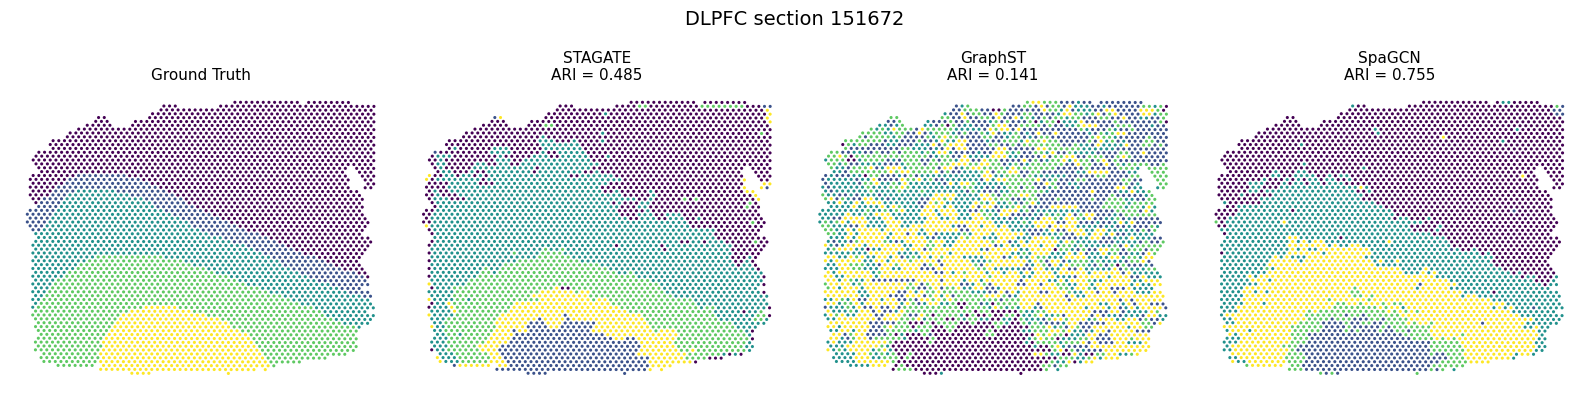

In [8]:
# ============================================================
# VISUALIZE SECTION 151672
# ============================================================

import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np

sec = "151672"

print("=" * 80)
print(f"VISUALIZING SECTION {sec}")
print("=" * 80)

# ------------------------------------------------------------
# Load section
# ------------------------------------------------------------

adata = sc.read_h5ad(
    f"data/DLPFC_{sec}_ST_final.h5ad"
)

n_clusters = (
    adata.obs["Ground Truth"]
    .nunique()
)

coords = np.asarray(
    adata.obsm["spatial"]
)

print("Spots:", adata.n_obs)
print("Ground-truth clusters:", n_clusters)


# ============================================================
# STAGATE
# ============================================================

print("\nRunning STAGATE...")

adata_st, emb_st = run_stagate(
    adata
)

pred_st = cluster_embedding(
    emb_st,
    n_clusters
)

ari_st, nmi_st = evaluate_clustering(
    adata,
    pred_st
)

print(
    f"STAGATE — ARI: {ari_st:.3f}, "
    f"NMI: {nmi_st:.3f}"
)


# ============================================================
# GraphST
# ============================================================

print("\nRunning GraphST...")

adata_gs, emb_gs = run_graphst(
    adata
)

pred_gs = cluster_embedding(
    emb_gs,
    n_clusters
)

ari_gs, nmi_gs = evaluate_clustering(
    adata,
    pred_gs
)

print(
    f"GraphST — ARI: {ari_gs:.3f}, "
    f"NMI: {nmi_gs:.3f}"
)


# ============================================================
# SpaGCN
# ============================================================

print("\nRunning SpaGCN...")

adata_sp, emb_sp = run_spagcn(
    adata
)

pred_sp = cluster_embedding(
    emb_sp,
    n_clusters
)

ari_sp, nmi_sp = evaluate_clustering(
    adata,
    pred_sp
)

print(
    f"SpaGCN — ARI: {ari_sp:.3f}, "
    f"NMI: {nmi_sp:.3f}"
)


# ============================================================
# SAVE PREDICTIONS
# ============================================================

np.save(
    f"experiment_c_embeddings/{sec}_STAGATE_labels.npy",
    pred_st
)

np.save(
    f"experiment_c_embeddings/{sec}_GraphST_labels.npy",
    pred_gs
)

np.save(
    f"experiment_c_embeddings/{sec}_SpaGCN_labels.npy",
    pred_sp
)


# ============================================================
# PREPARE GROUND TRUTH
# ============================================================

ground_truth = (
    adata.obs["Ground Truth"]
    .astype(str)
    .values
)


# Convert labels to categorical integers
# so each panel can be plotted consistently.
gt_categories = np.unique(ground_truth)

gt_numeric = np.array([
    np.where(gt_categories == x)[0][0]
    for x in ground_truth
])


# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)


plots = [
    (
        gt_numeric,
        "Ground Truth"
    ),
    (
        pred_st,
        f"STAGATE\nARI = {ari_st:.3f}"
    ),
    (
        pred_gs,
        f"GraphST\nARI = {ari_gs:.3f}"
    ),
    (
        pred_sp,
        f"SpaGCN\nARI = {ari_sp:.3f}"
    )
]


for ax, (labels, title) in zip(
    axes,
    plots
):

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=labels,
        s=5,
        linewidths=0
    )

    ax.set_title(
        title,
        fontsize=11
    )

    ax.invert_yaxis()
    ax.axis("off")


plt.suptitle(
    f"DLPFC section {sec}",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    f"experiment_c_plots/{sec}_spatial_clustering.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()